# NB02 — LoRA Training

ใน notebook นี้เราจะเทรน per-species LoRA บน FLUX.2-klein ให้ 15 rare species แบบ DreamBooth: ผูก identity ของแต่ละ species เข้ากับ trigger `sks_<species_id>` ผ่าน caption แล้วใช้ recipe เดียวกันหมดทุกตัว (fixed epochs) เทรนเฉพาะภาพ train split กัน leak เข้า test

output หลักคือ LoRA weights ต่อ species ที่ `models/lora/<species_id>/` + `nb02_handoff.json` ที่ NB03 เอาไป generate ต่อ

## Section 1) Setup & smoke test

ตั้ง path, โหลด `splits.csv` + `species.csv` จาก NB01 เช็คว่า input มาครบ แล้ว smoke test โหลด FLUX.2-klein รันบน GPU 


In [15]:
from pathlib import Path
import pandas as pd

ROOT = Path('/workspace/lora-boost')
DATA = ROOT / 'data'
META = DATA / 'metadata'
IMG_ROOT = DATA / 'raw' / 'plantnet_300K' / 'images'
LORA_TRAIN = DATA / 'lora_train'
MODELS = ROOT / 'models' / 'lora'
RESULTS = ROOT / 'results' / 'nb02'
SCRIPT = ROOT / 'scripts' / 'train_dreambooth_lora_flux2_klein.py'

for p in [LORA_TRAIN, MODELS, RESULTS]:
    p.mkdir(parents=True, exist_ok=True)

BASE_MODEL = 'black-forest-labs/FLUX.2-klein-base-4B'

splits_df = pd.read_csv(META / 'splits.csv', dtype={'species_id': str})
species_df = pd.read_csv(META / 'species.csv', dtype={'species_id': str})

print(f'splits.csv   :\t{len(splits_df):,} rows')
print(f'species.csv  :\t{species_df.species_id.nunique()} species')
print(f'rare flagged :\t{int(species_df.is_rare.sum())}')
print(f'IMG_ROOT     :\t{IMG_ROOT.exists()}')
print(f'engine       :\t{SCRIPT.exists()}')

splits.csv   :	239,932 rows
species.csv  :	399 species
rare flagged :	15
IMG_ROOT     :	True
engine       :	True


In [16]:
import torch
import diffusers

cap = torch.cuda.get_device_capability()
sm = f'sm_{cap[0]}{cap[1]}'
arch_list = torch.cuda.get_arch_list()
vram = torch.cuda.get_device_properties(0).total_memory / 1e9

print(f'torch        :\t{torch.__version__}')
print(f'torch cuda   :\t{torch.version.cuda}')
print(f'diffusers    :\t{diffusers.__version__}')
print(f'gpu          :\t{torch.cuda.get_device_name(0)}')
print(f'capability   :\t{sm}')
print(f'vram         :\t{vram:.0f} GB')
print(f'bf16 ok      :\t{torch.cuda.is_bf16_supported()}')
print(f'arch_list    :\t{arch_list}')

# sm_120 trap: torch ต้อง build รองรับ sm_120 
problems = []
if sm not in arch_list:
    problems.append(f'{sm} ไม่อยู่ใน arch_list -> ใช้ template CUDA 12.8+/torch 2.6+ แล้ว redeploy')
if not torch.cuda.is_bf16_supported():
    problems.append('bf16 ไม่รองรับ')
try:
    from diffusers import Flux2KleinPipeline
    print(f'Flux2Klein   :\timportable')
except ImportError:
    problems.append('Flux2KleinPipeline import ไม่ได้ -> pip install -U git+https://github.com/huggingface/diffusers.git')

print()
print('ENV OK' if not problems else 'ENV PROBLEMS:')
for p in problems:
    print(f'  - {p}')

torch        :	2.8.0+cu128
torch cuda   :	12.8
diffusers    :	0.39.0.dev0
gpu          :	NVIDIA RTX PRO 4500 Blackwell
capability   :	sm_120
vram         :	34 GB
bf16 ok      :	True
arch_list    :	['sm_70', 'sm_75', 'sm_80', 'sm_86', 'sm_90', 'sm_100', 'sm_120']
Flux2Klein   :	importable

ENV OK


Loading pipeline components...:   0%|          | 0/5 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

  0%|          | 0/8 [00:00<?, ?it/s]

output size :	(512, 512)
vram peak   :	16.7 GB
saved       :	/workspace/lora-boost/results/nb02/smoke_test.png


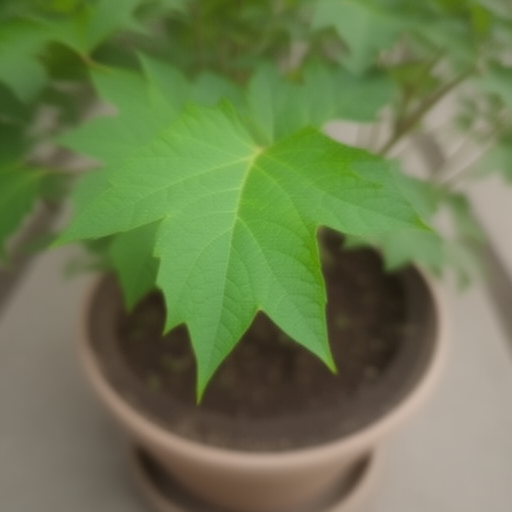

In [26]:
import torch
from diffusers import Flux2KleinPipeline

pipe = Flux2KleinPipeline.from_pretrained(cfg['base_model'], torch_dtype=torch.bfloat16).to('cuda')

img = pipe(
    prompt='a photo of a potted plant, the leaf',
    num_inference_steps=8,
    guidance_scale=4.0,
    height=512, width=512,
    generator=torch.Generator('cuda').manual_seed(42),
).images[0]

out = RESULTS / 'smoke_test.png'
img.save(out)
vram_peak = torch.cuda.max_memory_allocated() / 1e9
print(f'output size :\t{img.size}')
print(f'vram peak   :\t{vram_peak:.1f} GB')
print(f'saved       :\t{out}')
display(img)

## Section 2) Config

รวมค่า hyperparameter การเทรนทั้งหมดไว้ใน `cfg` ที่เดียว section หลังดึงไปใช้ แก้จุดเดียวมีผลทั้ง notebook จากนั้นโหลด `splits.csv` กรองเฉพาะ rare species ใน train split นับภาพต่อ species กำหนด pilot จากตัวที่ภาพน้อยสุด

In [42]:
cfg = {
    'base_model': BASE_MODEL,
    'rank': 8,
    'lora_alpha': 8,                                   # = rank, scale 1.0
    'lr': 1e-4,
    'lr_scheduler': 'constant',
    'lr_warmup_steps': 0,                           
    'epochs': 100,                                    # ล็อกใน Section 5 หลัง pilot
    'ckpt_every': 250,
    'batch': 1,
    'grad_accum': 4,                                   # effective batch 4
    'resolution': 1024,
    'mixed_precision': 'bf16',
    'seed': 42,
    'trigger_prefix': 'sks_',
    'caption_tmpl': 'a photo of the {organ} of a {trigger} plant',
    'gen_defaults': {'steps': 28, 'guidance': 4.0, 'res': 1024},
    'select': {'fid_min': 0.50, 'mem_max': 0.05, 'clipt_min': 0.22},
}

for k, v in cfg.items():
    print(f'{k:16}:\t{v}')

base_model      :	black-forest-labs/FLUX.2-klein-base-4B
rank            :	8
lora_alpha      :	8
lr              :	0.0001
lr_scheduler    :	constant
lr_warmup_steps :	0
epochs          :	100
ckpt_every      :	250
batch           :	1
grad_accum      :	4
resolution      :	1024
mixed_precision :	bf16
seed            :	42
trigger_prefix  :	sks_
caption_tmpl    :	a photo of the {organ} of a {trigger} plant
gen_defaults    :	{'steps': 28, 'guidance': 4.0, 'res': 1024}
select          :	{'fid_min': 0.5, 'mem_max': 0.05, 'clipt_min': 0.22}


In [19]:
import pandas as pd

rare_ids = species_df.loc[species_df.is_rare, 'species_id'].tolist()
rare_train = splits_df[(splits_df.is_rare) & (splits_df.split == 'train')]

n_train = rare_train.groupby('species_id').size()
name_map = species_df.set_index('species_id')['scientific_name']
organ_mix = rare_train.groupby('species_id')['organ'].value_counts().unstack(fill_value=0)

summary = pd.DataFrame({'n_train': n_train})
summary['flower'] = organ_mix.get('flower', 0)
summary['leaf'] = organ_mix.get('leaf', 0)
summary['name'] = name_map
summary = summary.sort_values('n_train')

pilot_sid = summary.index[0]

print(f'rare species :\t{len(rare_ids)}')
print(f'train images :\t{len(rare_train):,}')
print(f'pilot        :\t{pilot_sid} ({name_map[pilot_sid]}) n_train={summary.iloc[0].n_train}')
print()
print(summary[['name', 'n_train', 'flower', 'leaf']].to_string())

rare species :	15
train images :	644
pilot        :	1416509 (Nepenthes vieillardii Hook. f.) n_train=20

                                            name  n_train  flower  leaf
species_id                                                             
1416509           Nepenthes vieillardii Hook. f.       20       8    12
1419807     Vanilla planifolia Jacks. ex Andrews       23       6    17
1376703                    Petiveria alliacea L.       28       7    21
1409195                  Pereskia aculeata Mill.       33       8    25
1408557             Pongamia pinnata (L.) Pierre       36      11    25
1406486           Kigelia africana (Lam.) Benth.       37      16    21
1420787           Alocasia odora (Lindl.) K.Koch       38       7    31
1408490                Pereskia grandifolia Haw.       40      29    11
1385700          Barringtonia asiatica (L.) Kurz       47      26    21
1356076     Tradescantia zebrina Heynh. ex Bosse       49       7    42
1397598                     Cob

## Section 3) Build training data

สร้างโฟลเดอร์ imagefolder ต่อ rare species ที่ `data/lora_train/<species_id>/` copy ภาพ train split พร้อมเขียน `metadata.jsonl` (caption ต่อภาพ trigger `sks_<id>` + organ จาก splits) engine อ่าน caption ผ่าน `--dataset_name` ตอนเทรน

In [24]:
import json
import shutil

total = 0
for sid, grp in rare_train.groupby('species_id'):
    dst = LORA_TRAIN / sid
    dst.mkdir(parents=True, exist_ok=True)
    trigger = cfg['trigger_prefix'] + sid
    lines = []
    for r in grp.itertuples():
        fn = f'{r.image_id}.jpg'
        if not (dst / fn).exists():
            shutil.copy(IMG_ROOT / r.path, dst / fn)
        caption = cfg['caption_tmpl'].format(trigger=trigger, organ=r.organ)
        lines.append({'file_name': fn, 'text': caption})
    with open(dst / 'metadata.jsonl', 'w') as f:
        for ln in lines:
            f.write(json.dumps(ln) + '\n')
    total += len(lines)

pilot_dir = LORA_TRAIN / pilot_sid
meta = [json.loads(l) for l in open(pilot_dir / 'metadata.jsonl')]

print(f'species built :\t{rare_train.species_id.nunique()}')
print(f'images copied :\t{total:,}')
print(f'pilot folder  :\t{pilot_dir.name}')
print(f'pilot images  :\t{len(list(pilot_dir.glob("*.jpg")))}')
print(f'pilot meta    :\t{len(meta)} rows')
print(f'caption flower:\t{next(m["text"] for m in meta if "flower" in m["text"])}')
print(f'caption leaf  :\t{next(m["text"] for m in meta if "leaf" in m["text"])}')

species built :	15
images copied :	644
pilot folder  :	1416509
pilot images  :	20
pilot meta    :	20 rows
caption flower:	a photo of the flower of a sks_1416509 plant
caption leaf  :	a photo of the leaf of a sks_1416509 plant


## Section 4) Training function & pilot

`build_cmd` ประกอบ CLI args จาก `cfg` รัน engine ผ่าน `accelerate launch` แบบ single process caption ต่อภาพอ่านผ่าน `--dataset_name` ปิด final inference ของ engine จากนั้น pilot 2 ตัว เทรนยาว save ถี่ ตัวภาพน้อยสุด (Nepenthes) เป็น lower bound และ prior-fighter (Pereskia) เป็นตัวที่ FLUX มี prior แย่ง ครอบทั้งสองความเสี่ยงก่อนล็อก epoch ใน Section 5

In [27]:
def build_cmd(sid, epochs, ckpt_every):
    return [
        'accelerate', 'launch', '--num_processes', '1', str(SCRIPT),
        '--pretrained_model_name_or_path', cfg['base_model'],
        '--dataset_name', str(LORA_TRAIN / sid),
        '--image_column', 'image',
        '--caption_column', 'text',
        '--instance_prompt', 'a plant',
        '--output_dir', str(MODELS / sid),
        '--rank', str(cfg['rank']),
        '--lora_alpha', str(cfg['lora_alpha']),
        '--learning_rate', str(cfg['lr']),
        '--lr_scheduler', cfg['lr_scheduler'],
        '--lr_warmup_steps', str(cfg['lr_warmup_steps']),
        '--num_train_epochs', str(epochs),
        '--checkpointing_steps', str(ckpt_every),
        '--train_batch_size', str(cfg['batch']),
        '--gradient_accumulation_steps', str(cfg['grad_accum']),
        '--resolution', str(cfg['resolution']),
        '--mixed_precision', cfg['mixed_precision'],
        '--seed', str(cfg['seed']),
        '--skip_final_inference',
    ]

cmd = build_cmd(pilot_sid, epochs=150, ckpt_every=100)
print(' '.join(cmd))

accelerate launch --num_processes 1 /workspace/lora-boost/scripts/train_dreambooth_lora_flux2_klein.py --pretrained_model_name_or_path black-forest-labs/FLUX.2-klein-base-4B --dataset_name /workspace/lora-boost/data/lora_train/1416509 --image_column image --caption_column text --instance_prompt a plant --output_dir /workspace/lora-boost/models/lora/1416509 --rank 8 --lora_alpha 8 --learning_rate 0.0001 --lr_scheduler constant --lr_warmup_steps 0 --num_train_epochs 150 --checkpointing_steps 100 --train_batch_size 1 --gradient_accumulation_steps 4 --resolution 1024 --mixed_precision bf16 --seed 42 --skip_final_inference


In [30]:
import subprocess

def train_one(sid, epochs, ckpt_every):
    cmd = build_cmd(sid, epochs, ckpt_every)
    proc = subprocess.Popen(cmd, stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True, bufsize=1)
    for line in proc.stdout:
        print(line, end='')
    proc.wait()
    return proc.returncode

rc = train_one(pilot_sid, epochs=150, ckpt_every=100)
print(f'\nreturn code :\t{rc}')

The following values were not passed to `accelerate launch` and had defaults used instead:
	`--num_machines` was set to a value of `1`
	`--mixed_precision` was set to a value of `'no'`
	`--dynamo_backend` was set to a value of `'no'`
To avoid this warning pass in values for each of the problematic parameters or run `accelerate config`.
/usr/local/lib/python3.12/dist-packages/accelerate/accelerator.py:528: UserWarning: `log_with=tensorboard` was passed but no supported trackers are currently installed.
  warnings.warn(f"`log_with={log_with}` was passed but no supported trackers are currently installed.")
05/26/2026 19:30:22 - INFO - __main__ - [RANK 0] Distributed environment: DistributedType.NO
Num processes: 1
Process index: 0
Local process index: 0
Device: cuda

Mixed precision type: bf16

05/26/2026 19:30:22 - INFO - httpx - HTTP Request: HEAD https://huggingface.co/black-forest-labs/FLUX.2-klein-base-4B/resolve/main/tokenizer/tokenizer_config.json "HTTP/1.1 307 Temporary Redirect"


In [36]:
pereskia_sid = '1408490'
rc = train_one(pereskia_sid, epochs=150, ckpt_every=100)
print(f'\nreturn code :\t{rc}')

The following values were not passed to `accelerate launch` and had defaults used instead:
	`--num_machines` was set to a value of `1`
	`--mixed_precision` was set to a value of `'no'`
	`--dynamo_backend` was set to a value of `'no'`
To avoid this warning pass in values for each of the problematic parameters or run `accelerate config`.
/usr/local/lib/python3.12/dist-packages/accelerate/accelerator.py:528: UserWarning: `log_with=tensorboard` was passed but no supported trackers are currently installed.
  warnings.warn(f"`log_with={log_with}` was passed but no supported trackers are currently installed.")
05/27/2026 02:31:27 - INFO - __main__ - [RANK 0] Distributed environment: DistributedType.NO
Num processes: 1
Process index: 0
Local process index: 0
Device: cuda

Mixed precision type: bf16

05/27/2026 02:31:27 - INFO - httpx - HTTP Request: HEAD https://huggingface.co/black-forest-labs/FLUX.2-klein-base-4B/resolve/main/tokenizer/tokenizer_config.json "HTTP/1.1 307 Temporary Redirect"


## Section 5) Pilot review & epoch selection

โหลด base ครั้งเดียวแล้วสวม LoRA ทีละ checkpoint gen รูปเทียบด้วยตาก่อน แล้ววัด fidelity (DINOv2 cosine กับ centroid ภาพจริง) และ memorization (สัดส่วนภาพ gen ที่ใกล้ภาพ train) ตัดสิน epoch ด้วย metric แทนการมองด้วยตาคน plot บนแกน epoch เดียวกันทั้งสองตัว เลือก epoch ที่ fidelity ดีและ memorization ต่ำ ล็อกลง cfg

In [37]:
import torch
from diffusers import Flux2KleinPipeline

pipe = Flux2KleinPipeline.from_pretrained(cfg['base_model'], torch_dtype=torch.bfloat16).to('cuda')
print(f'base loaded :\t{cfg["base_model"]}')
print(f'vram        :\t{torch.cuda.memory_allocated() / 1e9:.1f} GB')

Loading pipeline components...:   0%|          | 0/5 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

base loaded :	black-forest-labs/FLUX.2-klein-base-4B
vram        :	16.0 GB


  0%|          | 0/28 [00:00<?, ?it/s]

  0%|          | 0/28 [00:00<?, ?it/s]

step 100   :	done


  0%|          | 0/28 [00:00<?, ?it/s]

  0%|          | 0/28 [00:00<?, ?it/s]

...

  0%|          | 0/28 [00:00<?, ?it/s]

step 600   :	done


  0%|          | 0/28 [00:00<?, ?it/s]

  0%|          | 0/28 [00:00<?, ?it/s]

step 700   :	done


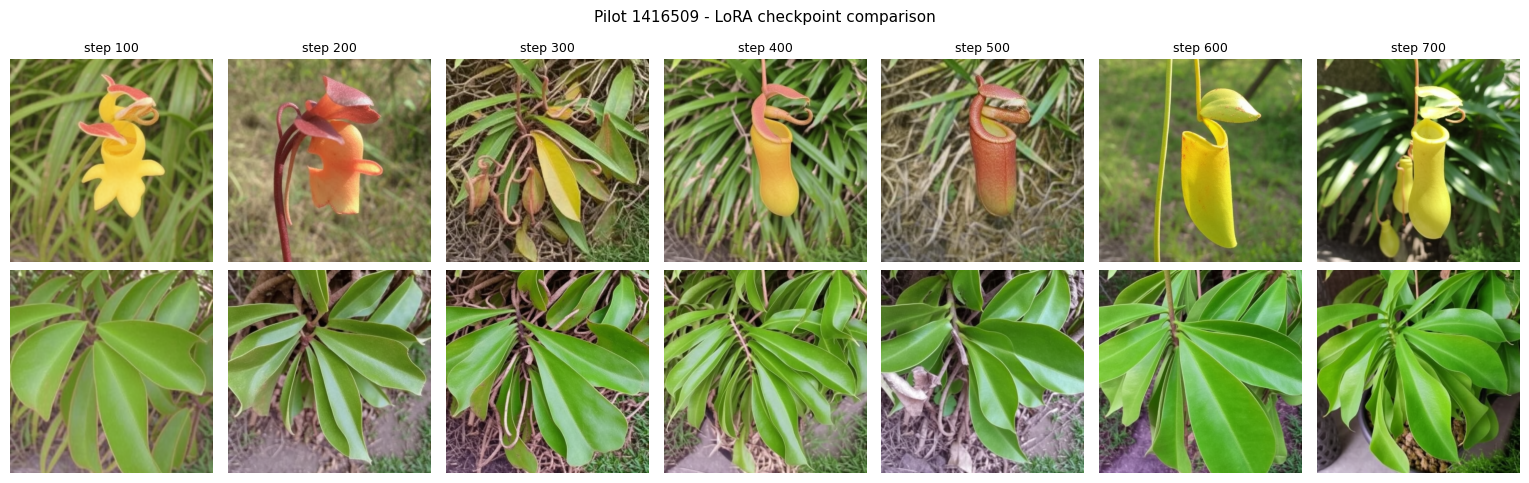

In [34]:
import matplotlib.pyplot as plt

prompts = {
    'flower': f'a photo of the flower of a {cfg["trigger_prefix"]}{pilot_sid} plant',
    'leaf': f'a photo of the leaf of a {cfg["trigger_prefix"]}{pilot_sid} plant',
}
steps = [100, 200, 300, 400, 500, 600, 700]
out_dir = RESULTS / 'pilot'
out_dir.mkdir(parents=True, exist_ok=True)

grid = {'flower': [], 'leaf': []}
for st in steps:
    ckpt = MODELS / pilot_sid / f'checkpoint-{st}' / 'pytorch_lora_weights.safetensors'
    pipe.load_lora_weights(str(ckpt))
    for organ, pr in prompts.items():
        img = pipe(
            prompt=pr,
            num_inference_steps=cfg['gen_defaults']['steps'],
            guidance_scale=cfg['gen_defaults']['guidance'],
            height=cfg['gen_defaults']['res'], width=cfg['gen_defaults']['res'],
            generator=torch.Generator('cuda').manual_seed(cfg['seed']),
        ).images[0]
        grid[organ].append(img)
    pipe.unload_lora_weights()
    print(f'step {st:3d}   :\tdone')

fig, axes = plt.subplots(2, len(steps), figsize=(len(steps) * 2.2, 5))
for col, st in enumerate(steps):
    for row, organ in enumerate(['flower', 'leaf']):
        axes[row, col].imshow(grid[organ][col])
        axes[row, col].axis('off')
        if row == 0:
            axes[row, col].set_title(f'step {st}', fontsize=9)
        if col == 0:
            axes[row, col].set_ylabel(organ, fontsize=9)
fig.suptitle(f'Pilot {pilot_sid} - LoRA checkpoint comparison', fontsize=11)
plt.tight_layout()
fig.savefig(out_dir / f'{pilot_sid}_checkpoints.png', dpi=120)
plt.show()

  0%|          | 0/28 [00:00<?, ?it/s]

  0%|          | 0/28 [00:00<?, ?it/s]

step  400  :	done


  0%|          | 0/28 [00:00<?, ?it/s]

  0%|          | 0/28 [00:00<?, ?it/s]

...

  0%|          | 0/28 [00:00<?, ?it/s]

step 1200  :	done


  0%|          | 0/28 [00:00<?, ?it/s]

  0%|          | 0/28 [00:00<?, ?it/s]

step 1500  :	done


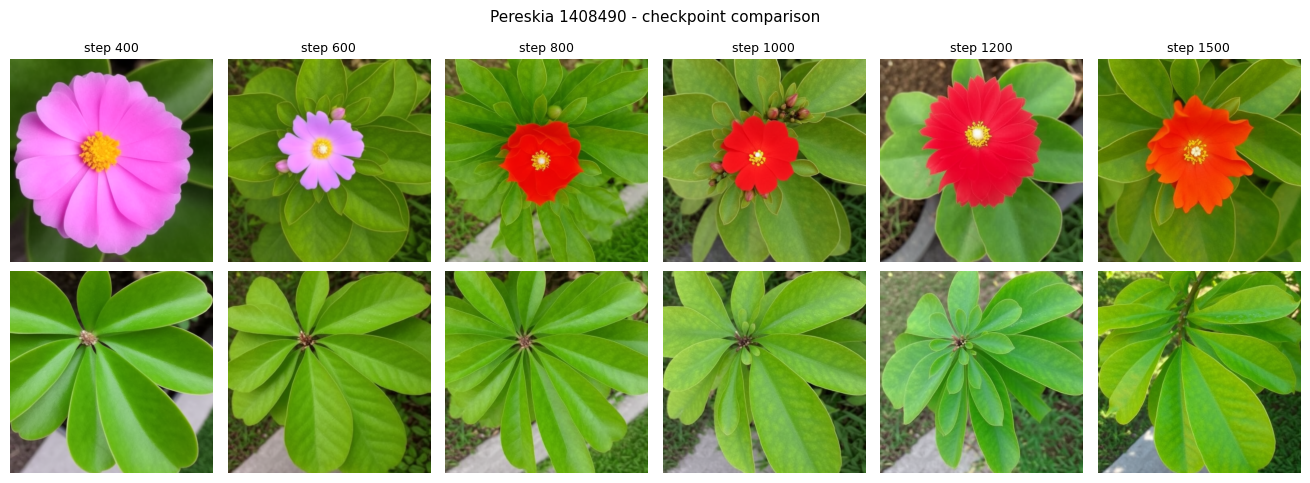

In [38]:
import matplotlib.pyplot as plt

prompts = {
    'flower': f'a photo of the flower of a {cfg["trigger_prefix"]}{pereskia_sid} plant',
    'leaf': f'a photo of the leaf of a {cfg["trigger_prefix"]}{pereskia_sid} plant',
}
steps = [400, 600, 800, 1000, 1200, 1500]
out_dir = RESULTS / 'pilot'

grid = {'flower': [], 'leaf': []}
for st in steps:
    ckpt = MODELS / pereskia_sid / f'checkpoint-{st}' / 'pytorch_lora_weights.safetensors'
    pipe.load_lora_weights(str(ckpt))
    for organ, pr in prompts.items():
        img = pipe(
            prompt=pr,
            num_inference_steps=cfg['gen_defaults']['steps'],
            guidance_scale=cfg['gen_defaults']['guidance'],
            height=cfg['gen_defaults']['res'], width=cfg['gen_defaults']['res'],
            generator=torch.Generator('cuda').manual_seed(cfg['seed']),
        ).images[0]
        grid[organ].append(img)
    pipe.unload_lora_weights()
    print(f'step {st:4d}  :\tdone')

fig, axes = plt.subplots(2, len(steps), figsize=(len(steps) * 2.2, 5))
for col, st in enumerate(steps):
    for row, organ in enumerate(['flower', 'leaf']):
        axes[row, col].imshow(grid[organ][col])
        axes[row, col].axis('off')
        if row == 0:
            axes[row, col].set_title(f'step {st}', fontsize=9)
fig.suptitle(f'Pereskia {pereskia_sid} - checkpoint comparison', fontsize=11)
plt.tight_layout()
fig.savefig(out_dir / f'{pereskia_sid}_checkpoints.png', dpi=120)
plt.show()

In [39]:
import timm
import torch.nn.functional as F
from PIL import Image

dino = timm.create_model('vit_base_patch14_reg4_dinov2.lvd142m', pretrained=True, num_classes=0).eval().to('cuda')
dino_tf = timm.data.create_transform(**timm.data.resolve_model_data_config(dino), is_training=False)

@torch.no_grad()
def dino_feat(imgs):
    x = torch.stack([dino_tf(im.convert('RGB')) for im in imgs]).to('cuda')
    return F.normalize(dino(x), dim=1)

def load_real_feat(sid):
    paths = sorted((LORA_TRAIN / sid).glob('*.jpg'))
    return dino_feat([Image.open(p) for p in paths])

real_feat = {pilot_sid: load_real_feat(pilot_sid), pereskia_sid: load_real_feat(pereskia_sid)}
for sid, f in real_feat.items():
    print(f'{sid}  :\treal feats {tuple(f.shape)}')

1416509  :	real feats (20, 768)
1408490  :	real feats (40, 768)


In [40]:
import numpy as np

@torch.no_grad()
def gen_eval(sid, step, n=8):
    ckpt = MODELS / sid / f'checkpoint-{step}' / 'pytorch_lora_weights.safetensors'
    pipe.load_lora_weights(str(ckpt))
    trigger = cfg['trigger_prefix'] + sid
    imgs = []
    for i in range(n):
        organ = 'flower' if i % 2 == 0 else 'leaf'
        img = pipe(
            prompt=f'a photo of the {organ} of a {trigger} plant',
            num_inference_steps=cfg['gen_defaults']['steps'],
            guidance_scale=cfg['gen_defaults']['guidance'],
            height=cfg['gen_defaults']['res'], width=cfg['gen_defaults']['res'],
            generator=torch.Generator('cuda').manual_seed(i),
        ).images[0]
        imgs.append(img)
    pipe.unload_lora_weights()
    gf = dino_feat(imgs)
    real = real_feat[sid]
    fidelity = (gf @ real.mean(0, keepdim=True).T).mean().item()
    sim = gf @ real.T
    memorization = (sim.max(1).values > 0.95).float().mean().item()
    return fidelity, memorization

def sweep(sid, steps):
    rows = []
    spe = len(list((LORA_TRAIN / sid).glob('*.jpg'))) / cfg['grad_accum']
    for st in steps:
        fid, mem = gen_eval(sid, st)
        rows.append({'step': st, 'epoch': round(st / spe), 'fid': fid, 'mem': mem})
        print(f'{sid} step {st:4d} (ep {rows[-1]["epoch"]:3d})  fid {fid:.3f}  mem {mem:.2f}')
    return rows

nep_rows = sweep(pilot_sid, [100, 200, 300, 400, 500, 600, 700])
print()
per_rows = sweep(pereskia_sid, [400, 600, 800, 1000, 1200, 1500])

  0%|          | 0/28 [00:00<?, ?it/s]

  0%|          | 0/28 [00:00<?, ?it/s]

  0%|          | 0/28 [00:00<?, ?it/s]

  0%|          | 0/28 [00:00<?, ?it/s]

  0%|          | 0/28 [00:00<?, ?it/s]

...

  0%|          | 0/28 [00:00<?, ?it/s]

  0%|          | 0/28 [00:00<?, ?it/s]

  0%|          | 0/28 [00:00<?, ?it/s]

  0%|          | 0/28 [00:00<?, ?it/s]

1408490 step 1500 (ep 150)  fid 0.311  mem 0.00


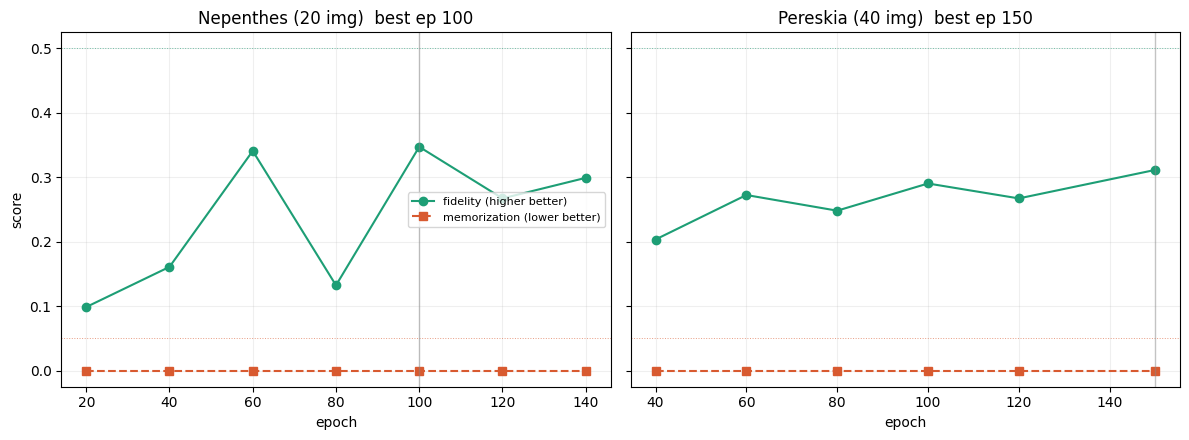

In [41]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)
for ax, rows, title in [(axes[0], nep_rows, 'Nepenthes (20 img)'),
                         (axes[1], per_rows, 'Pereskia (40 img)')]:
    ep = [r['epoch'] for r in rows]
    fid = [r['fid'] for r in rows]
    mem = [r['mem'] for r in rows]
    ax.plot(ep, fid, 'o-', color='#1d9e75', label='fidelity (higher better)')
    ax.plot(ep, mem, 's--', color='#d85a30', label='memorization (lower better)')
    ax.axhline(cfg['select']['mem_max'], color='#d85a30', lw=0.7, ls=':', alpha=0.6)
    ax.axhline(cfg['select']['fid_min'], color='#1d9e75', lw=0.7, ls=':', alpha=0.6)
    best = max(rows, key=lambda r: r['fid'] - (r['mem'] > cfg['select']['mem_max']) * 1)
    ax.axvline(best['epoch'], color='#888', lw=1, ls='-', alpha=0.5)
    ax.set_title(f'{title}  best ep {best["epoch"]}')
    ax.set_xlabel('epoch')
    ax.grid(alpha=0.2)
axes[0].set_ylabel('score')
axes[0].legend(fontsize=8, loc='center right')
plt.tight_layout()
fig.savefig(RESULTS / 'pilot' / 'metric_sweep.png', dpi=120)
plt.show()

### เลือก epochs : 100 (กลับไปแก้ใน config)

## Section 6) Batch training

เทรน LoRA ครบ 15 rare species ด้วย recipe เดียวกัน (epochs จาก cfg) idempotent guard ข้ามตัวที่ final weights มีแล้ว เขียน progress log เคลียร์ VRAM ก่อนทุกตัว ลบ weights pilot เก่า (150 epochs) ทิ้งก่อน ให้ทั้ง 15 ตัวใช้ epoch เท่ากัน

In [43]:
import shutil, torch, gc

for sid in [pilot_sid, pereskia_sid]:
    old = MODELS / sid
    if old.exists():
        shutil.rmtree(old)
        print(f'removed old :\t{sid}')

if 'pipe' in dir():
    del pipe
gc.collect()
torch.cuda.empty_cache()
print(f'allocated   :\t{torch.cuda.memory_allocated() / 1e9:.1f} GB')

removed old :	1416509
removed old :	1408490
allocated   :	0.4 GB


In [ ]:
import pandas as pd, time

PROGRESS = RESULTS / 'train_progress.csv'
rare_sids = species_df.loc[species_df.is_rare, 'species_id'].tolist()

done = set()
if PROGRESS.exists():
    done = set(pd.read_csv(PROGRESS, dtype={'species_id': str}).species_id)

for i, sid in enumerate(rare_sids):
    final = MODELS / sid / 'pytorch_lora_weights.safetensors'
    if final.exists():
        print(f'[{i+1}/15] {sid}  skip (done)')
        continue

    gc.collect()
    torch.cuda.empty_cache()
    print(f'[{i+1}/15] {sid}  training...')
    t0 = time.time()
    rc = train_one(sid, epochs=cfg['epochs'], ckpt_every=cfg['ckpt_every'])
    mins = (time.time() - t0) / 60

    row = pd.DataFrame([{'species_id': sid, 'rc': rc, 'minutes': round(mins, 1)}])
    row.to_csv(PROGRESS, mode='a', header=not PROGRESS.exists(), index=False)
    print(f'[{i+1}/15] {sid}  rc={rc}  {mins:.1f} min')

print(f'\ndone        :\t{(MODELS).glob("*/pytorch_lora_weights.safetensors") and sum(1 for _ in MODELS.glob("*/pytorch_lora_weights.safetensors"))} / 15')

[1/15] 1416509  training...
The following values were not passed to `accelerate launch` and had defaults used instead:
	`--num_machines` was set to a value of `1`
	`--mixed_precision` was set to a value of `'no'`
	`--dynamo_backend` was set to a value of `'no'`
To avoid this warning pass in values for each of the problematic parameters or run `accelerate config`.
/usr/local/lib/python3.12/dist-packages/accelerate/accelerator.py:528: UserWarning: `log_with=tensorboard` was passed but no supported trackers are currently installed.
  warnings.warn(f"`log_with={log_with}` was passed but no supported trackers are currently installed.")
05/27/2026 06:39:51 - INFO - __main__ - [RANK 0] Distributed environment: DistributedType.NO
Num processes: 1
Process index: 0
Local process index: 0
Device: cuda

Mixed precision type: bf16

05/27/2026 06:39:52 - INFO - httpx - HTTP Request: HEAD https://huggingface.co/black-forest-labs/FLUX.2-klein-base-4B/resolve/main/tokenizer/tokenizer_config.json "HTTP/

## Section 7) Evaluation

gen 30 รูปต่อ species จาก final weights วัด 4 metric เพื่อ flag ตัวที่พังชัดเจน ไม่ใช่จัดอันดับละเอียด (ตัวตัดสินจริงคือ macro F1 ใน NB04) ไม่แยก organ เพราะ classifier เทรนด้วย species label เป็นก้อนเดียว

- species consistency: DINOv2 cosine ของ gen กับเพื่อนบ้านภาพจริง top-3 (เป็นสายพันธุ์นั้นไหม)
- memorization: สัดส่วนรูป gen ที่ cosine > 0.95 กับภาพ train (ลอกภาพไหม)
- diversity: 1 - cosine เฉลี่ยระหว่างรูป gen กันเอง (collapse ไหม)
- organ accuracy: gen flower/leaf ตรง prompt ไหม

In [50]:
from transformers import CLIPModel, CLIPProcessor

clip_model = CLIPModel.from_pretrained('openai/clip-vit-base-patch32').eval().to('cuda')
clip_proc = CLIPProcessor.from_pretrained('openai/clip-vit-base-patch32')

@torch.no_grad()
def clip_score(imgs, prompts):
    inp = clip_proc(text=prompts, images=imgs, return_tensors='pt', padding=True).to('cuda')
    out = clip_model(**inp)
    img_emb = F.normalize(out.image_embeds, dim=1)
    txt_emb = F.normalize(out.text_embeds, dim=1)
    return (img_emb * txt_emb).sum(1)

rare_sids = species_df.loc[species_df.is_rare, 'species_id'].tolist()
for sid in rare_sids:
    if sid not in real_feat:
        real_feat[sid] = load_real_feat(sid)

print(f'clip loaded :\t{type(clip_model).__name__}')
print(f'real_feat   :\t{len(real_feat)} species')
print(f'vram        :\t{torch.cuda.memory_allocated() / 1e9:.1f} GB')

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

clip loaded :	CLIPModel
real_feat   :	15 species
vram        :	17.0 GB


In [54]:
@torch.no_grad()
def organ_accuracy(imgs, organs):
    labels = ['a photo of a flower', 'a photo of a leaf']
    inp = clip_proc(text=labels, images=imgs, return_tensors='pt', padding=True).to('cuda')
    out = clip_model(**inp)
    txt = F.normalize(out.text_embeds, dim=1)
    img = F.normalize(out.image_embeds, dim=1)
    pred = (img @ txt.T).argmax(1).cpu()
    true = torch.tensor([0 if o == 'flower' else 1 for o in organs])
    return (pred == true).float().mean().item()


@torch.no_grad()
def eval_one(sid, n=30, k=3):
    pipe.load_lora_weights(str(MODELS / sid / 'pytorch_lora_weights.safetensors'))
    trigger = cfg['trigger_prefix'] + sid

    imgs, organs = [], []
    for i in range(n):
        organ = 'flower' if i % 2 == 0 else 'leaf'
        pr = f'a photo of the {organ} of a {trigger} plant'
        img = pipe(prompt=pr, num_inference_steps=cfg['gen_defaults']['steps'],
                   guidance_scale=cfg['gen_defaults']['guidance'],
                   height=cfg['gen_defaults']['res'], width=cfg['gen_defaults']['res'],
                   generator=torch.Generator('cuda').manual_seed(i)).images[0]
        imgs.append(img); organs.append(organ)
    pipe.unload_lora_weights()

    gf = dino_feat(imgs)
    real = real_feat[sid]
    sim = gf @ real.T
    topk = sim.topk(k, dim=1).values.mean(1)
    n_gen = gf.shape[0]
    mask = torch.triu(torch.ones(n_gen, n_gen), 1).bool()

    return {
        'species_id': sid,
        'consistency': round(topk.mean().item(), 3),
        'memorization': round((sim.max(1).values > 0.95).float().mean().item(), 3),
        'diversity': round((1 - (gf @ gf.T)[mask]).mean().item(), 3),
        'organ_acc': round(organ_accuracy(imgs, organs), 3),
    }

In [ ]:
import gc

if 'pipe' not in dir():
    gc.collect()
    torch.cuda.empty_cache()
    pipe = Flux2KleinPipeline.from_pretrained(cfg['base_model'], torch_dtype=torch.bfloat16).to('cuda')
    print(f'pipe loaded :\t{torch.cuda.memory_allocated() / 1e9:.1f} GB')

rows = []
for i, sid in enumerate(rare_sids):
    m = eval_one(sid)
    rows.append(m)
    print(f'[{i+1}/15] {sid}  cons {m["consistency"]:.2f}  mem {m["memorization"]:.2f}  div {m["diversity"]:.2f}  organ {m["organ_acc"]:.2f}')

eval_df = pd.DataFrame(rows)
eval_df.to_csv(RESULTS / 'lora_eval.csv', index=False)
print(f'\nsaved       :\t{RESULTS / "lora_eval.csv"}')

  0%|          | 0/28 [00:00<?, ?it/s]

  0%|          | 0/28 [00:00<?, ?it/s]

  0%|          | 0/28 [00:00<?, ?it/s]

  0%|          | 0/28 [00:00<?, ?it/s]

  0%|          | 0/28 [00:00<?, ?it/s]

...

  0%|          | 0/28 [00:00<?, ?it/s]

  0%|          | 0/28 [00:00<?, ?it/s]

  0%|          | 0/28 [00:00<?, ?it/s]

  0%|          | 0/28 [00:00<?, ?it/s]

  0%|          | 0/28 [00:00<?, ?it/s]

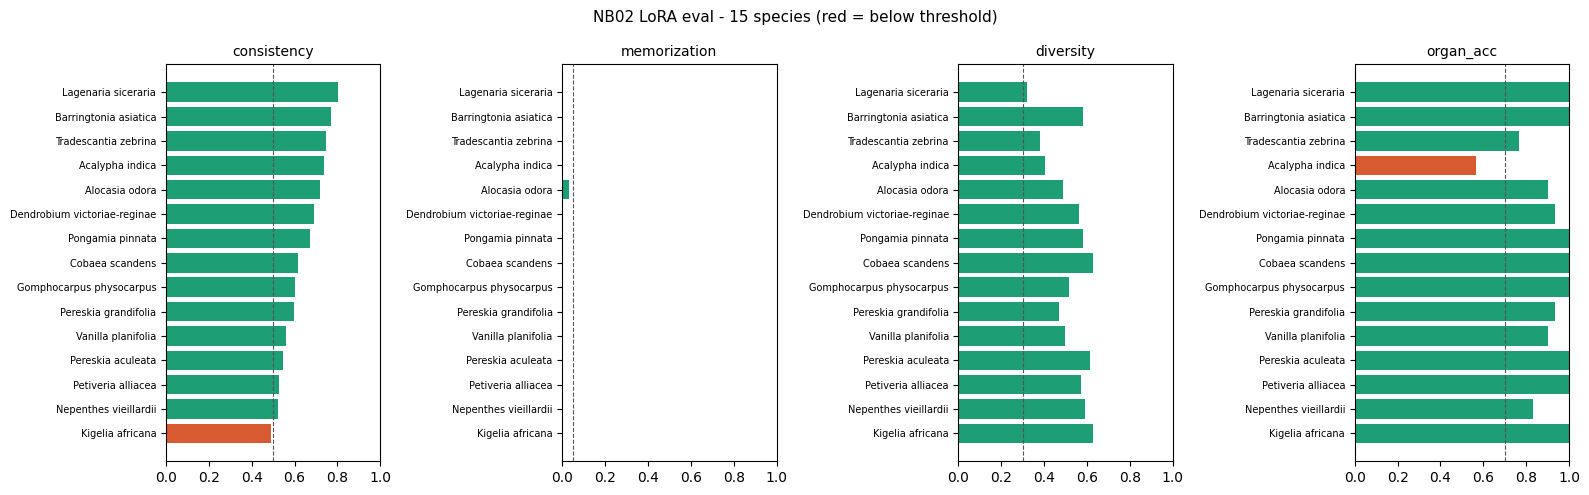

In [58]:
import matplotlib.pyplot as plt

eval_df = pd.read_csv(RESULTS / 'lora_eval.csv', dtype={'species_id': str})
eval_df['name'] = eval_df.species_id.map(species_df.set_index('species_id')['scientific_name'].str.split().str[:2].str.join(' '))
eval_df = eval_df.sort_values('consistency')

metrics = ['consistency', 'memorization', 'diversity', 'organ_acc']
thresh = {'consistency': 0.50, 'memorization': 0.05, 'diversity': 0.30, 'organ_acc': 0.70}
low_good = {'memorization'}

fig, axes = plt.subplots(1, 4, figsize=(16, 5))
for ax, met in zip(axes, metrics):
    vals = eval_df[met].values
    bad = vals > thresh[met] if met in low_good else vals < thresh[met]
    colors = ['#d85a30' if b else '#1d9e75' for b in bad]
    ax.barh(range(len(eval_df)), vals, color=colors)
    ax.axvline(thresh[met], color='#555', ls='--', lw=0.8)
    ax.set_yticks(range(len(eval_df)))
    ax.set_yticklabels(eval_df['name'], fontsize=7)
    ax.set_title(met, fontsize=10)
    ax.set_xlim(0, 1)
fig.suptitle('NB02 LoRA eval - 15 species (red = below threshold)', fontsize=11)
plt.tight_layout()
fig.savefig(RESULTS / 'lora_eval.png', dpi=120)
plt.show()

In [59]:
th = {'consistency': 0.50, 'memorization': 0.05, 'diversity': 0.30, 'organ_acc': 0.70}

def flag_row(r):
    reasons = []
    if r.consistency < th['consistency']: reasons.append('low_consistency')
    if r.memorization > th['memorization']: reasons.append('memorized')
    if r.diversity < th['diversity']: reasons.append('low_diversity')
    if r.organ_acc < th['organ_acc']: reasons.append('low_organ_acc')
    return ','.join(reasons) if reasons else 'ok'

eval_df['flag'] = eval_df.apply(flag_row, axis=1)
eval_df.to_csv(RESULTS / 'lora_eval.csv', index=False)

print(eval_df[['species_id', 'name', 'consistency', 'organ_acc', 'flag']].to_string(index=False))
print()
print(f'ok          :\t{(eval_df.flag == "ok").sum()} / 15')
print(f'flagged     :\t{eval_df[eval_df.flag != "ok"].species_id.tolist()}')

species_id                         name  consistency  organ_acc            flag
   1406486             Kigelia africana        0.492      1.000 low_consistency
   1416509        Nepenthes vieillardii        0.525      0.833              ok
   1376703           Petiveria alliacea        0.527      1.000              ok
   1409195            Pereskia aculeata        0.546      1.000              ok
   1419807           Vanilla planifolia        0.562      0.900              ok
   1408490         Pereskia grandifolia        0.596      0.933              ok
   1392654     Gomphocarpus physocarpus        0.600      1.000              ok
   1397598              Cobaea scandens        0.615      1.000              ok
   1408557             Pongamia pinnata        0.671      1.000              ok
   1618661 Dendrobium victoriae-reginae        0.689      0.933              ok
   1420787               Alocasia odora        0.718      0.900              ok
   1406863              Acalypha indica 

## Section 8) Handoff

สร้าง `lora_registry.csv` และ `nb02_handoff.json` รวมทุกอย่างที่ NB03 ต้องใช้ไว้ที่เดียว weights path, trigger, prompt template, gen params จากนั้น verify โหลด LoRA กลับมา gen ทดสอบว่าใช้ได้จริง

In [60]:
import json

def n_train(sid):
    return len(list((LORA_TRAIN / sid).glob('*.jpg')))

reg = []
for r in eval_df.itertuples():
    sid = r.species_id
    trigger = cfg['trigger_prefix'] + sid
    reg.append({
        'species_id': sid,
        'scientific_name': species_df.loc[species_df.species_id == sid, 'scientific_name'].iloc[0],
        'trigger': trigger,
        'prompt_template': cfg['caption_tmpl'].format(trigger=trigger, organ='{organ}'),
        'weights_path': str((MODELS / sid / 'pytorch_lora_weights.safetensors').relative_to(ROOT)),
        'n_train': n_train(sid),
        'flag': r.flag,
    })

reg_df = pd.DataFrame(reg)
reg_df.to_csv(META / 'lora_registry.csv', index=False)

print(reg_df[['species_id', 'trigger', 'weights_path', 'flag']].to_string(index=False))
print(f'\nsaved       :\t{META / "lora_registry.csv"}')

species_id     trigger                                         weights_path            flag
   1406486 sks_1406486 models/lora/1406486/pytorch_lora_weights.safetensors low_consistency
   1416509 sks_1416509 models/lora/1416509/pytorch_lora_weights.safetensors              ok
   1376703 sks_1376703 models/lora/1376703/pytorch_lora_weights.safetensors              ok
   1409195 sks_1409195 models/lora/1409195/pytorch_lora_weights.safetensors              ok
   1419807 sks_1419807 models/lora/1419807/pytorch_lora_weights.safetensors              ok
   1408490 sks_1408490 models/lora/1408490/pytorch_lora_weights.safetensors              ok
   1392654 sks_1392654 models/lora/1392654/pytorch_lora_weights.safetensors              ok
   1397598 sks_1397598 models/lora/1397598/pytorch_lora_weights.safetensors              ok
   1408557 sks_1408557 models/lora/1408557/pytorch_lora_weights.safetensors              ok
   1618661 sks_1618661 models/lora/1618661/pytorch_lora_weights.safetensors     

In [61]:
handoff = {
    'base_model': cfg['base_model'],
    'caption_tmpl': cfg['caption_tmpl'],
    'gen_defaults': cfg['gen_defaults'],
    'registry': str((META / 'lora_registry.csv').relative_to(ROOT)),
    'lora_dir': str((MODELS).relative_to(ROOT)),
    'n_species': len(reg_df),
    'n_ok': int((reg_df.flag == 'ok').sum()),
    'flagged': reg_df.loc[reg_df.flag != 'ok', ['species_id', 'flag']].to_dict('records'),
}

with open(META / 'nb02_handoff.json', 'w') as f:
    json.dump(handoff, f, indent=2)

print(json.dumps(handoff, indent=2))
print(f'\nsaved       :\t{META / "nb02_handoff.json"}')

{
  "base_model": "black-forest-labs/FLUX.2-klein-base-4B",
  "caption_tmpl": "a photo of the {organ} of a {trigger} plant",
  "gen_defaults": {
    "steps": 28,
    "guidance": 4.0,
    "res": 1024
  },
  "registry": "data/metadata/lora_registry.csv",
  "lora_dir": "models/lora",
  "n_species": 15,
  "n_ok": 13,
  "flagged": [
    {
      "species_id": "1406486",
      "flag": "low_consistency"
    },
    {
      "species_id": "1406863",
      "flag": "low_organ_acc"
    }
  ]
}

saved       :	/workspace/lora-boost/data/metadata/nb02_handoff.json


  0%|          | 0/28 [00:00<?, ?it/s]

loaded from :	models/lora/1406486/pytorch_lora_weights.safetensors
prompt      :	a photo of the flower of a sks_1406486 plant
output      :	(512, 512)


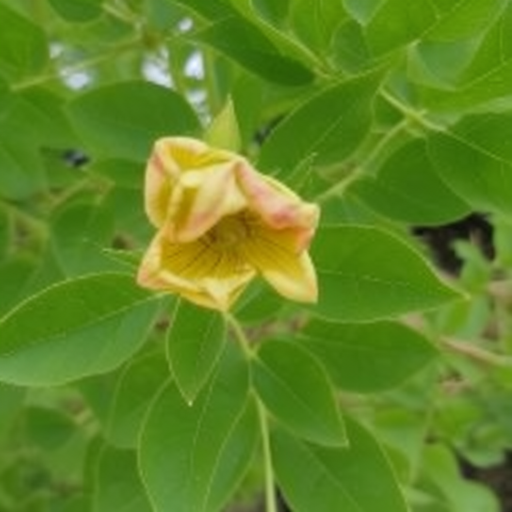

In [62]:
import torch

test = reg_df.iloc[0]
sid = test.species_id

pipe.load_lora_weights(str(ROOT / test.weights_path))
prompt = test.prompt_template.format(organ='flower')
img = pipe(prompt=prompt, num_inference_steps=cfg['gen_defaults']['steps'],
           guidance_scale=cfg['gen_defaults']['guidance'],
           height=512, width=512,
           generator=torch.Generator('cuda').manual_seed(0)).images[0]
pipe.unload_lora_weights()

print(f'loaded from :\t{test.weights_path}')
print(f'prompt      :\t{prompt}')
print(f'output      :\t{img.size}')
display(img)